In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv(r"D:\Project_Alpha\Raw_data.csv")

In [3]:
df.head()

,drugname,CountyName,AverageMiles,PercentMailOrder (%)
0,Insulin,Alameda County,7.16,33.5
1,Insulin,Amador County,16.92,35.3
2,Insulin,Butte County,14.50,11.1
3,Insulin,Calaveras County,19.58,21.8
4,Insulin,Colusa County,18.74,16.8


In [4]:
df.columns

Index(['drugname', 'CountyName', 'AverageMiles', 'PercentMailOrder (%)'], dtype='str')

In [5]:
df.isnull().sum()

drugname                0
CountyName              0
AverageMiles            0
PercentMailOrder (%)    0
dtype: int64

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   drugname              114 non-null    str    
 1   CountyName            114 non-null    str    
 2   AverageMiles          114 non-null    float64
 3   PercentMailOrder (%)  114 non-null    float64
dtypes: float64(2), str(2)
memory usage: 3.7 KB


In [14]:
df = df.map(lambda x: str(x).strip())

In [16]:
convert_dict = {'AverageMiles': float,'PercentMailOrder (%)': float}
df=df.astype(convert_dict)
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 114 entries, 0 to 113
Data columns (total 4 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   drugname              114 non-null    str    
 1   CountyName            114 non-null    str    
 2   AverageMiles          114 non-null    float64
 3   PercentMailOrder (%)  114 non-null    float64
dtypes: float64(2), str(2)
memory usage: 3.7 KB


In [17]:


# 2. Define the regional groups for California
north_ca = {
    'Sutter County', 'Solano County', 'Humboldt County', 'Placer County', 'Yolo County', 
    'Del Norte County', 'El Dorado County', 'Sonoma County', 'Glenn County', 'Butte County', 
    'Lake County', 'Nevada County', 'Yuba County', 'Tehama County', 'Shasta County', 
    'Siskiyou County', 'Colusa County', 'Plumas County', 'Lassen County', 'Trinity County', 
    'Modoc County', 'Mendocino County', 'Sierra County', 'Sacramento County', 'Napa County',
    'Marin County', 'Contra Costa County', 'Alameda County', 'San Francisco County', 'San Mateo County'
}

central_ca = {
    'San Joaquin County', 'Fresno County', 'Stanislaus County', 'Kings County', 
    'Merced County', 'Madera County', 'Tulare County', 'Tuolumne County', 
    'Amador County', 'Calaveras County', 'Mariposa County', 'Inyo County', 
    'Mono County', 'Santa Clara County', 'Santa Cruz County', 'Monterey County', 
    'San Benito County', 'San Luis Obispo County', 'Kern County'
}

south_ca = {
    'Orange County', 'Los Angeles County', 'Ventura County', 'San Diego County', 
    'Santa Barbara County', 'San Bernardino County', 'Riverside County', 'Imperial County'
}

# 3. Create the conditions for pandas
conditions = [
    df['CountyName'].isin(north_ca),
    df['CountyName'].isin(central_ca),
    df['CountyName'].isin(south_ca)
]

regions = ['North California', 'Central California', 'South California']

# 4. Bin them instantly
df['CA_Region'] = np.select(conditions, regions, default='Unknown')

In [19]:
df.head()

,drugname,CountyName,AverageMiles,PercentMailOrder (%),CA_Region
0,Insulin,Alameda County,7.16,33.5,North California
1,Insulin,Amador County,16.92,35.3,Central California
2,Insulin,Butte County,14.50,11.1,North California
3,Insulin,Calaveras County,19.58,21.8,Central California
4,Insulin,Colusa County,18.74,16.8,North California


In [27]:
df['AverageMiles'].describe()


count    114.000000
mean      11.365526
std        5.069420
min        4.150000
25%        7.590000
50%        9.870000
75%       13.962500
max       25.910000
Name: AverageMiles, dtype: float64

In [30]:

bin_edges = [0, 10, 20, 30]
bin_labels = ['Low Miles', 'Medium Miles', 'High Miles']

df['Mileage_Range'] = pd.cut(df['AverageMiles'], bins=bin_edges, labels=bin_labels)

print(df[['AverageMiles', 'Mileage_Range']])

     AverageMiles Mileage_Range
0            7.16     Low Miles
1           16.92  Medium Miles
2           14.50  Medium Miles
3           19.58  Medium Miles
4           18.74  Medium Miles
..            ...           ...
109          9.87     Low Miles
110         12.57  Medium Miles
111          5.34     Low Miles
112          6.09     Low Miles
113         12.01  Medium Miles

[114 rows x 2 columns]


In [31]:
df.head(10)

,drugname,CountyName,AverageMiles,PercentMailOrder (%),CA_Region,Mileage_Range
0,Insulin,Alameda County,7.16,33.5,North California,Low Miles
1,Insulin,Amador County,16.92,35.3,Central California,Medium Miles
2,Insulin,Butte County,14.50,11.1,North California,Medium Miles
3,Insulin,Calaveras County,19.58,21.8,Central California,Medium Miles
4,Insulin,Colusa County,18.74,16.8,North California,Medium Miles
5,Insulin,Contra Costa County,7.46,35.5,North California,Low Miles
6,Insulin,Del Norte County,8.54,21.2,North California,Low Miles
7,Insulin,El Dorado County,11.17,33.3,North California,Medium Miles
8,Insulin,Fresno County,10.75,16.7,Central California,Medium Miles
9,Insulin,Glenn County,11.86,16.5,North California,Medium Miles


In [35]:
import matplotlib.pyplot as plt
import seaborn as sns

Text(0, 0.5, 'Count')

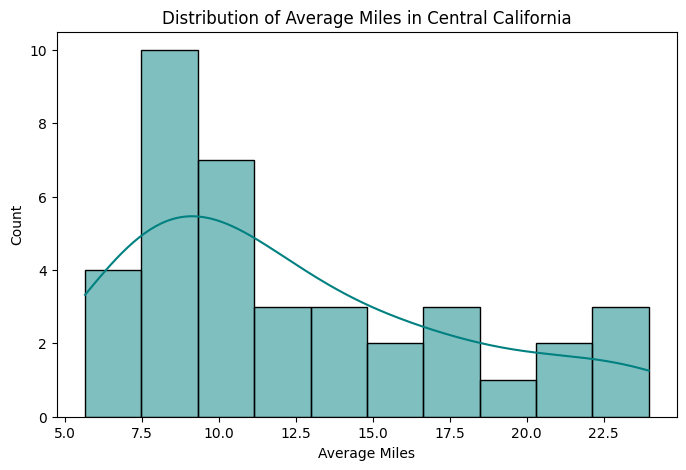

In [43]:
north_data = df[df['CA_Region'] == 'Central California']

# 2. Plot the histogram for that specific region
plt.figure(figsize=(8, 5))
sns.histplot(data=north_data, x='AverageMiles', bins=10, color='teal', kde=True)

# 3. Add labels
plt.title('Distribution of Average Miles in Central California')
plt.xlabel('Average Miles')
plt.ylabel('Count')

In [46]:
df.columns

Index(['drugname', 'CountyName', 'AverageMiles', 'PercentMailOrder (%)',
       'CA_Region', 'Mileage_Range'],
      dtype='str')

Text(0, 0.5, 'Count')

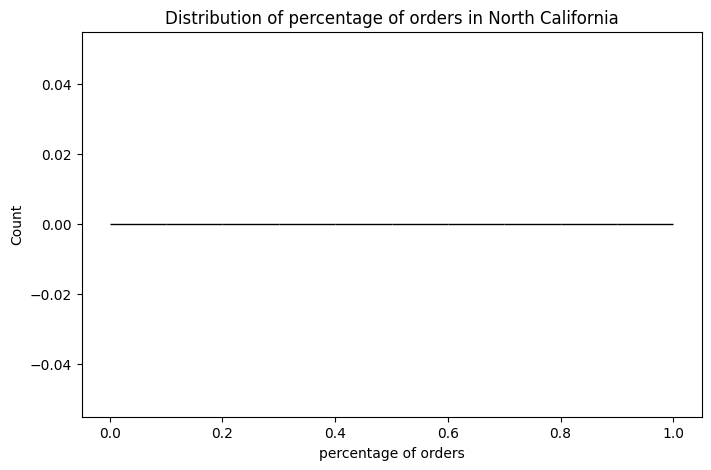

In [ ]:
north_data = df[df['PercentMailOrder (%)'] and df['CA_Region'] = 'North California']

# 2. Plot the histogram for that specific region
plt.figure(figsize=(8, 5))
sns.histplot(data=north_data, x='AverageMiles', bins=10, color='teal', kde=True)

# 3. Add labels
plt.title('Distribution of percentage of orders in North California')
plt.xlabel('percentage of orders')
plt.ylabel('Count')

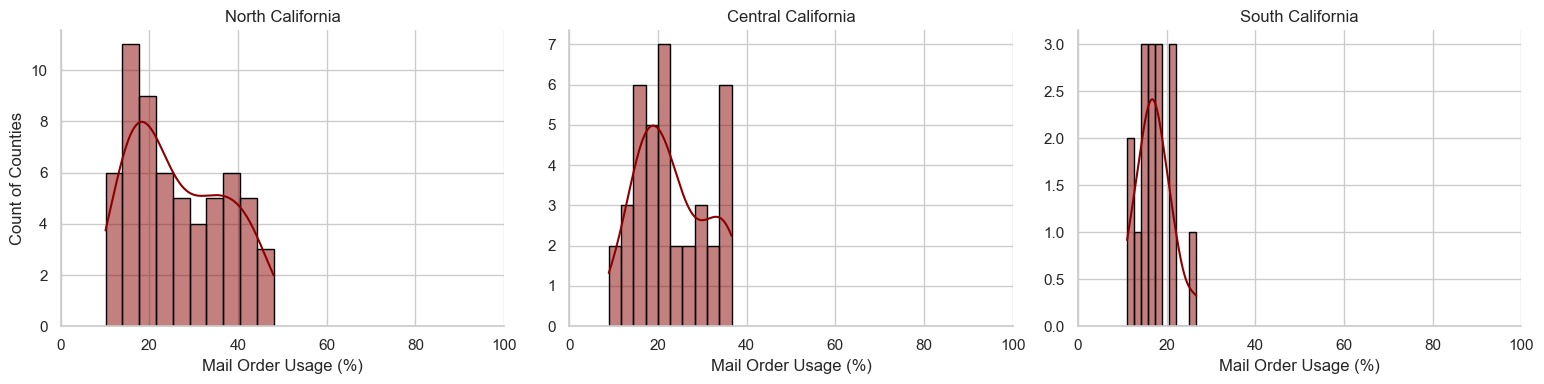

In [49]:
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Set up a clean, modern plotting style
sns.set_theme(style="whitegrid")

# 2. Create a side-by-side comparison grid for each region
# We use sharex=True so the 0% to 100% scale matches perfectly across all charts
g = sns.FacetGrid(df, col="CA_Region", sharey=False, height=4, aspect=1.3)

# 3. Map the histogram and bell curve onto the grid
g.map_dataframe(
    sns.histplot, 
    x="PercentMailOrder (%)", 
    bins=10, 
    kde=True, 
    color="darkred", 
    edgecolor="black"
)

# 4. Clean up labels and presentation
g.set_axis_labels("Mail Order Usage (%)", "Count of Counties")
g.set_titles(col_template="{col_name}")

# Ensure x-axis stays within realistic 0-100% bounds if needed
plt.xlim(0, 100) 

plt.tight_layout()
plt.show()

In [58]:
pd.crosstab(df['Mileage_Range'],df['drugname'])

drugname,Insulin,Metformin
Mileage_Range,,
Low Miles,23,37
Medium Miles,29,15
High Miles,5,5


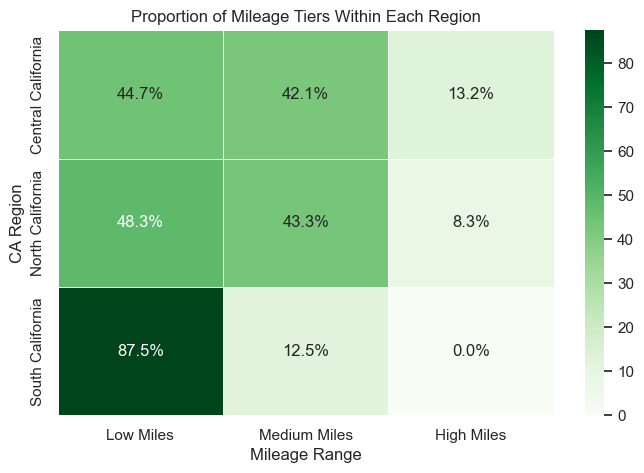

In [52]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Normalize by index (rows) to get percentages per region
ct_percent = pd.crosstab(df['CA_Region'], df['Mileage_Range'], normalize='index') * 100

# 2. Plot the percentage heatmap
plt.figure(figsize=(8, 5))
sns.heatmap(ct_percent, annot=True, cmap='Greens', fmt='.1f', linewidths=0.5)

# 3. Format annotations to show percentage signs
for t in plt.gca().texts:
    t.set_text(t.get_text() + '%')

plt.title('Proportion of Mileage Tiers Within Each Region')
plt.ylabel('CA Region')
plt.xlabel('Mileage Range')
plt.show()

In [54]:
df.corr(numeric_only=True)

,AverageMiles,PercentMailOrder (%)
AverageMiles,1.000000,-0.130283
PercentMailOrder (%),-0.130283,1.000000


Index(['drugname', 'CountyName', 'AverageMiles', 'PercentMailOrder (%)',
       'CA_Region', 'Mileage_Range'],
      dtype='str')

In [64]:
df.pivot_table(index="drugname",columns='Mileage_Range',values='AverageMiles',aggfunc=('mean','median'),observed=False)

mean                            median               \
Mileage_Range Low Miles Medium Miles High Miles Low Miles Medium Miles   
drugname                                                                 
Insulin        8.088261    14.167931     22.506      8.28        13.59   
Metformin      7.200541    13.708667     22.838      7.08        13.25   

                          
Mileage_Range High Miles  
drugname                  
Insulin            22.78  
Metformin          23.35

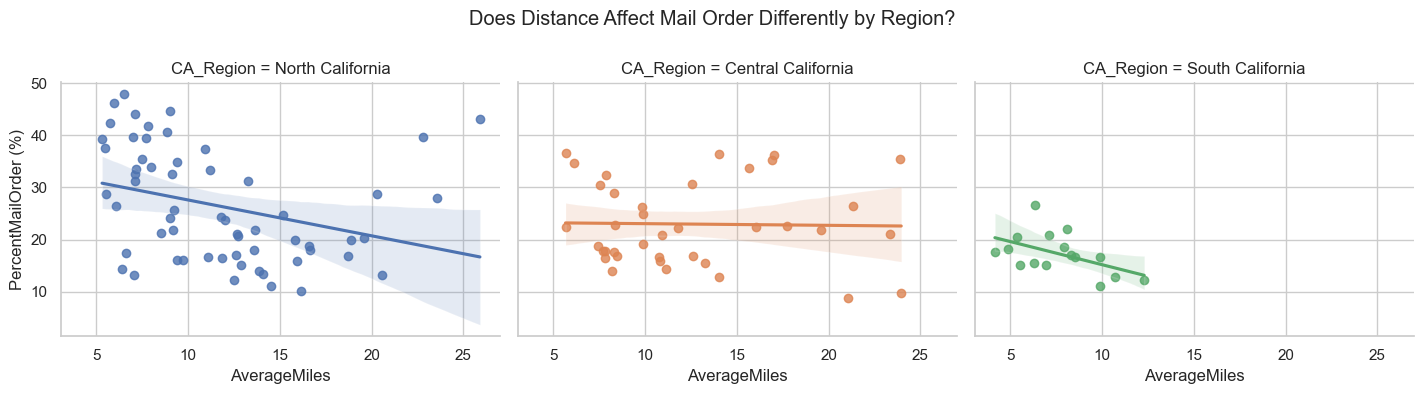

In [65]:
import seaborn as sns
import matplotlib.pyplot as plt

# Creates a separate scatter plot with a trendline for each region
sns.lmplot(
    data=df, 
    x="AverageMiles", 
    y="PercentMailOrder (%)", 
    col="CA_Region", 
    hue="CA_Region",
    height=4, 
    aspect=1.2
)

plt.subplots_adjust(top=0.8)
plt.suptitle("Does Distance Affect Mail Order Differently by Region?")
plt.show()

In [69]:
# Group by region and calculate correlation between the two numeric metrics
regional_corr = df.groupby('CA_Region')[['AverageMiles', 'PercentMailOrder (%)']].corr()

print(regional_corr)

                                         AverageMiles  PercentMailOrder (%)
CA_Region                                                                  
Central California AverageMiles              1.000000             -0.021485
                   PercentMailOrder (%)     -0.021485              1.000000
North California   AverageMiles              1.000000             -0.322703
                   PercentMailOrder (%)     -0.322703              1.000000
South California   AverageMiles              1.000000             -0.506788
                   PercentMailOrder (%)     -0.506788              1.000000


C:\Users\ACER\AppData\Local\Temp\ipykernel_9608\2411515362.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="CA_Region", y="AverageMiles", ax=axes[0], palette="Set2")
C:\Users\ACER\AppData\Local\Temp\ipykernel_9608\2411515362.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x="CA_Region", y="PercentMailOrder (%)", ax=axes[1], palette="Set2")


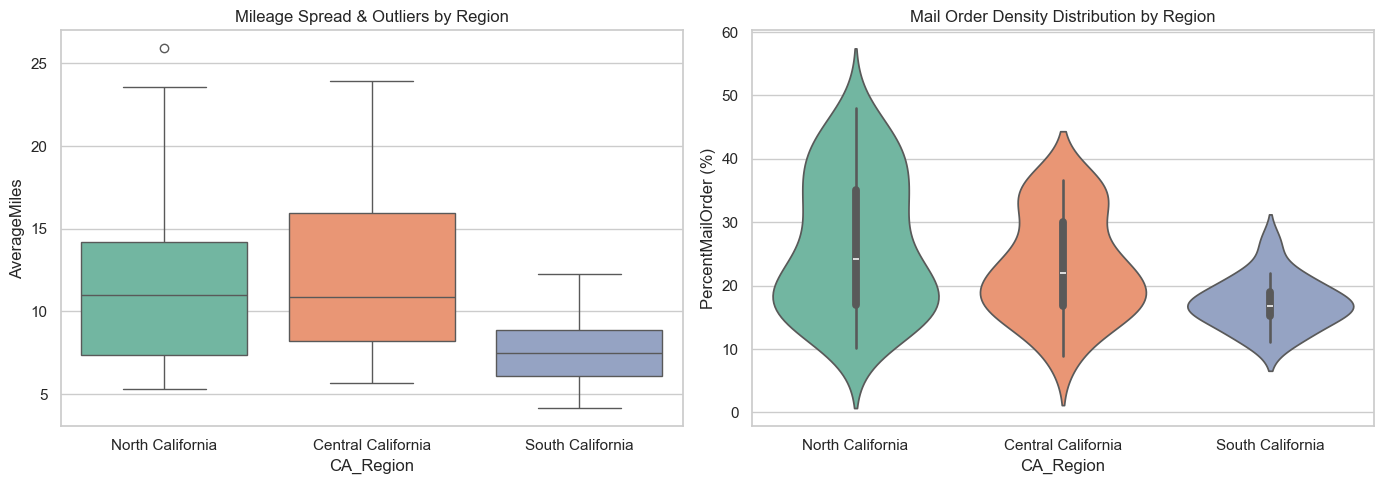

In [70]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Box Plot for Average Miles
sns.boxplot(data=df, x="CA_Region", y="AverageMiles", ax=axes[0], palette="Set2")
axes[0].set_title("Mileage Spread & Outliers by Region")

# 2. Violin Plot for Mail Order (Shows density + box plot inside)
sns.violinplot(data=df, x="CA_Region", y="PercentMailOrder (%)", ax=axes[1], palette="Set2")
axes[1].set_title("Mail Order Density Distribution by Region")

plt.tight_layout()
plt.show()

In [71]:
# Aggregate multiple metrics at once
regional_summary = df.groupby('CA_Region').agg({
    'AverageMiles': ['mean', 'median', 'max'],
    'PercentMailOrder (%)': ['mean', 'median', 'std']
}).round(2)

print(regional_summary)

                   AverageMiles               PercentMailOrder (%)         \
                           mean median    max                 mean median   
CA_Region                                                                   
Central California        12.45  10.88  23.96                22.99  22.00   
North California          11.67  11.01  25.91                26.46  24.20   
South California           7.63   7.51  12.29                17.30  16.85   

                           
                      std  
CA_Region                  
Central California   8.02  
North California    10.68  
South California     3.95  


In [72]:
# Find the average Mail Order % for each distinct pocket of data
pivot_analysis = df.pivot_table(
    values='PercentMailOrder (%)', 
    index='CA_Region', 
    columns='Mileage_Range', 
    aggfunc='mean'
).round(1)

print(pivot_analysis)

Mileage_Range       Low Miles  Medium Miles  High Miles
CA_Region                                              
Central California       23.4          23.4        20.3
North California         31.8          19.7        30.5
South California         18.0          12.6         NaN


In [75]:
pip install statsmodels


   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 3.5 MB/s eta 0:00:03
   ------ --------------------------------- 1.6/9.5 MB 3.7 MB/s eta 0:00:03
   ---------- ----------------------------- 2.6/9.5 MB 4.1 MB/s eta 0:00:02
   -------------- ------------------------- 3.4/9.5 MB 4.2 MB/s eta 0:00:02
   ------------------ --------------------- 4.5/9.5 MB 4.4 MB/s eta 0:00:02
   ----------------------- ---------------- 5.5/9.5 MB 4.4 MB/s eta 0:00:01
   --------------------------- ------------ 6.6/9.5 MB 4.5 MB/s eta 0:00:01
   ------------------------------ --------- 7.3/9.5 MB 4.4 MB/s eta 0:00:01
   ------------------------------------ --- 8.7/9.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------  9.4/9.5 MB 4.5 MB/s eta 0:00:01
   ---------------------------------------- 9.5/9.5 MB 4.0 MB/s eta 0:00:00
   ----------------


[notice] A new release of pip is available: 24.3.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [76]:
import statsmodels.api as sm

In [77]:


# Define your independent variable (X) and dependent variable (y)
X = sm.add_constant(df['AverageMiles'])
y = df['PercentMailOrder (%)']

# Fit the regression model
model = sm.OLS(y, X).fit()

# Print the statistical summary
print(model.summary())

                             OLS Regression Results                             
Dep. Variable:     PercentMailOrder (%)   R-squared:                       0.017
Model:                              OLS   Adj. R-squared:                  0.008
Method:                   Least Squares   F-statistic:                     1.934
Date:                  Tue, 23 Jun 2026   Prob (F-statistic):              0.167
Time:                          00:48:16   Log-Likelihood:                -418.36
No. Observations:                   114   AIC:                             840.7
Df Residuals:                       112   BIC:                             846.2
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const           26.8267     

In [78]:
df.to_excel("D:\Project_Alpha\Cleaned_Data.xlsx",index=False)

<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\ACER\AppData\Local\Temp\ipykernel_9608\911153312.py:1: SyntaxWarning: invalid escape sequence '\P'
  df.to_excel("D:\Project_Alpha\Cleaned_Data.xlsx",index=False)


In [81]:
# Pass drugname and region as a list to the index
drug_crosstab = pd.crosstab(
    index=[df['drugname'], df['CA_Region']], 
    columns=df['Mileage_Range']
)

print(drug_crosstab)

Mileage_Range                 Low Miles  Medium Miles  High Miles
drugname  CA_Region                                              
Insulin   Central California          5            11           3
          North California           12            16           2
          South California            6             2           0
Metformin Central California         12             5           2
          North California           17            10           3
          South California            8             0           0


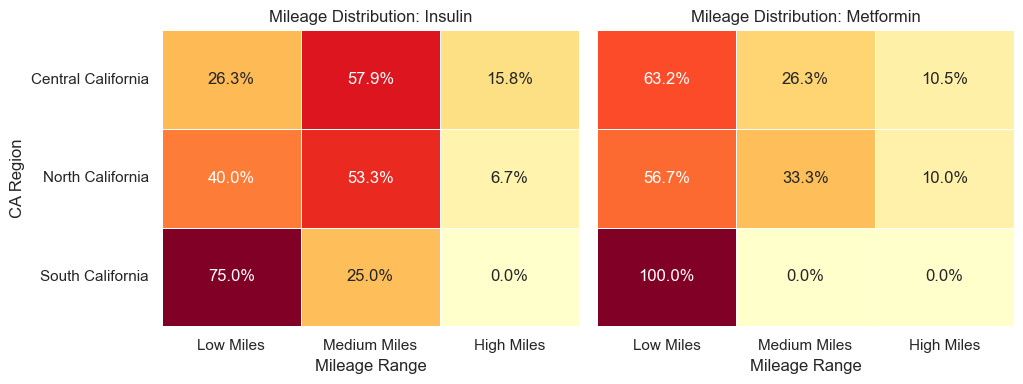

In [82]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Define a helper function to calculate the percentage crosstab and plot it
def draw_normalized_heatmap(data, **kwargs):
    # Calculate percentages per region (rows add up to 100%)
    ct = pd.crosstab(data['CA_Region'], data['Mileage_Range'], normalize='index') * 100
    
    # Draw the heatmap inside the grid cell
    sns.heatmap(ct, annot=True, fmt=".1f", cmap="YlOrRd", cbar=False, linewidths=0.5)
    
    # Append percent signs to the labels inside the squares
    for t in plt.gca().texts:
        t.set_text(t.get_text() + '%')

# 2. Use FacetGrid to create a column for each unique drug name
g = sns.FacetGrid(df, col="drugname", height=4, aspect=1.3)
g.map_dataframe(draw_normalized_heatmap)

# 3. Polish the layout and titles
g.set_titles(col_template="Mileage Distribution: {col_name}")
g.set_axis_labels("Mileage Range", "CA Region")

plt.tight_layout()
plt.show()

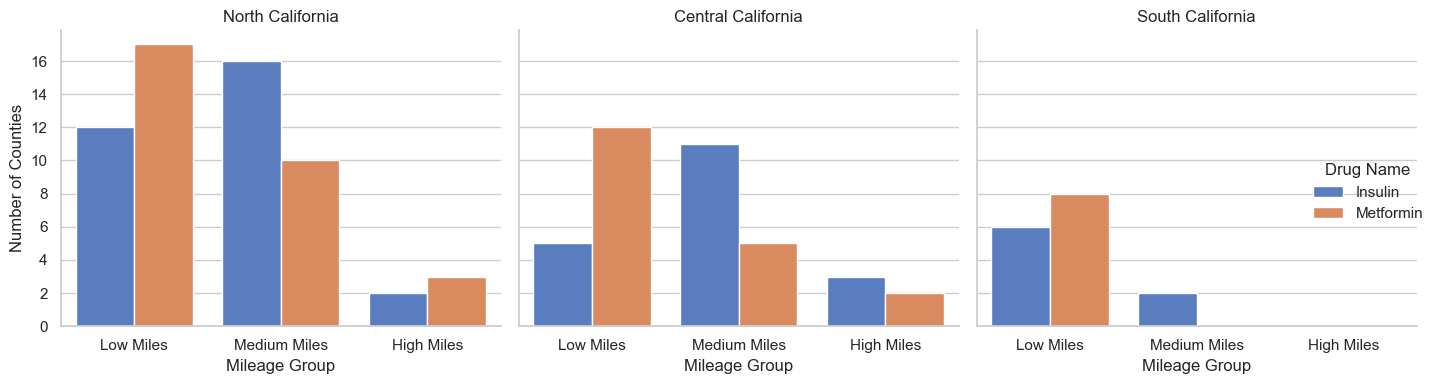

In [84]:
import seaborn as sns
import matplotlib.pyplot as plt

# Using catplot automatically creates the grid and draws the counts
g = sns.catplot(
    data=df, 
    x="Mileage_Range", 
    hue="drugname", 
    col="CA_Region", 
    kind="count", 
    height=4, 
    aspect=1.1,
    palette="muted"
)

# Clean up axes and titles
g.set_axis_labels("Mileage Group", "Number of Counties")
g.set_titles(col_template="{col_name}")
g.legend.set_title("Drug Name")

plt.tight_layout()
plt.show()

In [85]:
df.columns

Index(['drugname', 'CountyName', 'AverageMiles', 'PercentMailOrder (%)',
       'CA_Region', 'Mileage_Range'],
      dtype='str')

In [86]:
drug_corr = df.groupby('drugname')[['AverageMiles', 'PercentMailOrder (%)']].corr()

print(drug_corr)

                                AverageMiles  PercentMailOrder (%)
drugname                                                          
Insulin   AverageMiles              1.000000             -0.108753
          PercentMailOrder (%)     -0.108753              1.000000
Metformin AverageMiles              1.000000             -0.067826
          PercentMailOrder (%)     -0.067826              1.000000
